In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label

In [2]:
df = pd.read_csv("/Users/ruch/Desktop/ML-Engineer/Core/Machine Learning/Data/8-fraud_detection.csv")
df.head()

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [3]:
df['is_fraud'].unique()

array([0, 1])

In [4]:
df["is_fraud"].value_counts()

is_fraud
0    9846
1     154
Name: count, dtype: int64

In [5]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

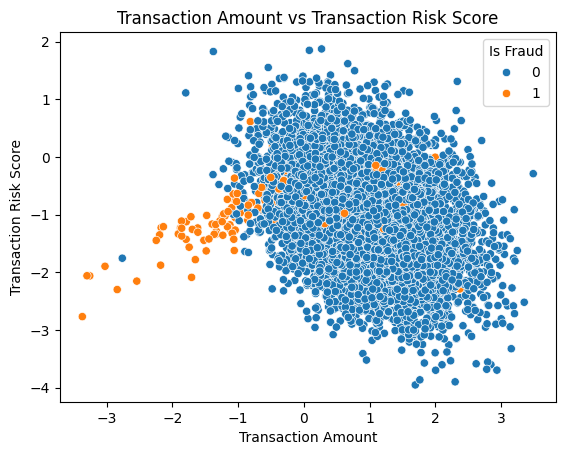

In [6]:
sns.scatterplot(x = X["transaction_amount"], y = X["transaction_risk_score"], hue=y, data=df)
plt.title("Transaction Amount vs Transaction Risk Score")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Risk Score")
plt.legend(title="Is Fraud", loc='upper right')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [9]:
penalty = ['l1', 'l2', 'elasticnet']
c_values = [0.01, 0.1, 1, 10, 100]
solver = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga', 'newton-cholesky']
class_weight = [{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [10]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [11]:
params = dict(penalty=penalty, C=c_values, solver=solver, class_weight=class_weight)

In [12]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
grid = GridSearchCV(estimator=model, param_grid=params, cv=cv, n_jobs=-1, scoring='accuracy')

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
grid.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The ma

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga', 'newton-cholesky']},
             scoring='accuracy')

In [17]:
y_pred = grid.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [19]:
score = accuracy_score(y_pred, y_test)
print("score:" , score)
confusion_matrix_score = confusion_matrix(y_pred, y_test)
print("confusion matrix: \n", confusion_matrix_score)
classification_report_score = classification_report(y_pred, y_test)
print("classification report: \n", classification_report_score)

score: 0.9888
confusion matrix: 
 [[2459   22]
 [   6   13]]
classification report: 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.37      0.68      0.48        19

    accuracy                           0.99      2500
   macro avg       0.68      0.84      0.74      2500
weighted avg       0.99      0.99      0.99      2500



In [20]:
grid.best_score_

0.9881333333333332

In [21]:
grid.best_params_

{'C': 0.01,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [22]:
# ROC and AUC

The ROC Curve is a graphical representation of a classification model’s performance across different threshold values. It plots the True Positive Rate (Recall) on the Y-axis against the False Positive Rate (1 - Specificity) on the X-axis. • A model that perfectly distinguishes between classes has a curve that reaches the top-left corner. • The closer the curve is to the top-left, the better the model. • The area under the ROC curve (AUC) quantifies this performance: • AUC = 1 → perfect classifier • AUC = 0.5 → random guessing

ROC is especially useful for imbalanced datasets, as it evaluates the model independent of class distribution or threshold.

In [42]:
model_probs = grid.predict_proba(X_test)

In [43]:
model_probs

array([[0.83925024, 0.16074976],
       [0.9881502 , 0.0118498 ],
       [0.86607697, 0.13392303],
       ...,
       [0.83554919, 0.16445081],
       [0.96834681, 0.03165319],
       [0.93184074, 0.06815926]])

In [44]:
model_probs = model_probs[:, 1] # probabilities for the positive class
model_probs

array([0.16074976, 0.0118498 , 0.13392303, ..., 0.16445081, 0.03165319,
       0.06815926])

In [45]:
from sklearn.metrics import roc_auc_score, roc_curve

In [46]:
model_auc = roc_auc_score(y_pred, model_probs)
model_auc

1.0

In [47]:
model_fpr, model_tpr, thresholds = roc_curve(y_test, model_probs)

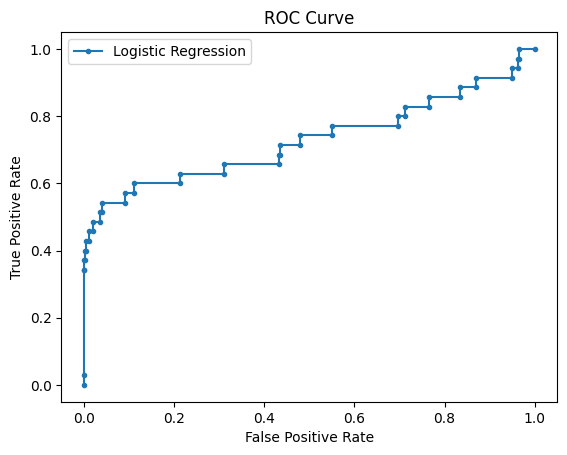

In [48]:
plt.plot(model_fpr, model_tpr, marker='.', label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

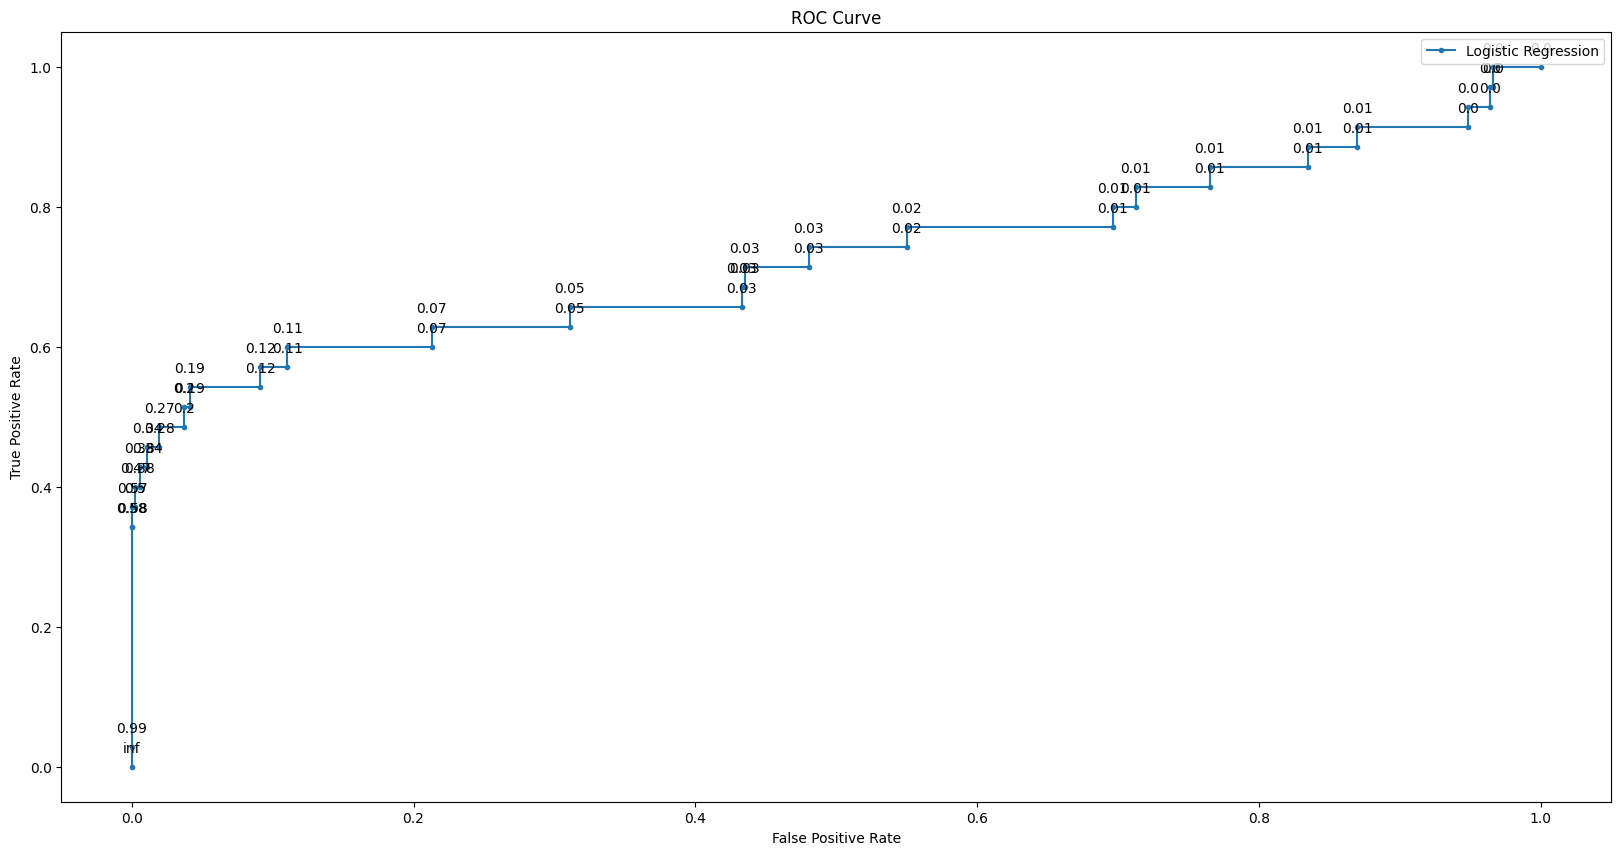

In [50]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(20, 10))

# Plot ROC curve
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic Regression')

# Annotate each point with the threshold
for fpr, tpr, thresh in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f'{np.round(thresh, 2)}', (fpr, tpr), textcoords="offset points", xytext=(0,10), ha='center')

# Labels and legend
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# Show the plot
plt.show()

In [53]:
custom_threshold = 0.3

y_pred_custom = (model_probs >= custom_threshold).astype(int)

print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom, y_test))

[[2423   19]
 [  42   16]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2442
           1       0.46      0.28      0.34        58

    accuracy                           0.98      2500
   macro avg       0.72      0.63      0.67      2500
weighted avg       0.97      0.98      0.97      2500

